# 2D Grayscale Image Fitting with gsplat (Orthographic Projection)

Fit a 2D grayscale image using 3D Gaussians rendered through the **full gsplat pipeline**
(projection → binning → compositing) with orthographic camera.

**Pipeline:**
$$\text{Gaussians} \xrightarrow{\text{ortho proj}} \text{gsplat compositing} \rightarrow \text{image} \xrightarrow{\text{MSE}} \text{loss} \rightarrow \text{update}$$

**Approach:**
- Parameterize N 3D Gaussians with means $(x_i, y_i, z_i)$, quaternions, scales, color, opacity
- $(x_i, y_i)$ correspond to image coordinates; $z_i$ is a latent depth for compositing order
- Use `gsplat.rasterization()` with `camera_model="ortho"` — no custom kernels needed
- Grayscale image is broadcast to 3-channel RGB for gsplat compatibility
- Single scalar intensity per Gaussian replicated across RGB channels

## 1. Imports and Setup

In [ ]:
# !pip install zarr ipywidgets scikit-image pandas torch_dct huffman scikit-learn

In [ ]:
import sys, math, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch

import lovely_tensors as lt
lt.monkey_patch()

# ── Project path ──────────────────────────────────────────────────────────
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

# ── gsplat_compress library ───────────────────────────────────────────────
import gsplat_compress as gc
from gsplat_compress import (
    GaussianParams, init_gaussians, ortho_camera, render,
    TrainConfig, FinetuneConfig, TrainResult,
    train_keyframe, finetune_frame,
    CodebookConfig, CompressedFrame,
    compute_deltas, build_codebook, finetune_codebook,
    encode_delta_frame, reconstruct_compressed_frame,
    psnr, ssim, mse, keyframe_bytes, delta_frame_bytes,
    raw_frame_bytes, compression_ratio, sequence_storage_summary,
    D_FULL, D_EFF, PARAMS_PER_GAUSSIAN_EFF, PARAMS_PER_GAUSSIAN_FULL,
    S_M, S_S, S_Q, S_R, S_O,
)

# ── Data loading ──────────────────────────────────────────────────────────
from inct.dataset_slices import ProjectionSliceDataset

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['image.cmap'] = 'gray'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}  |  PyTorch {torch.__version__}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name()}")
print("✅ Imports ready")

## 2. Load Target Image

Load the first projection from `ProjectionSliceDataset` and prepare it as a grayscale target.

  Loaded 50/50
Volume shape: (1024, 1024, 50)
Total voxels: 52,428,800
Value range: [-0.0746, 1.5249]

Target image: (1024, 1024)
Range: [0.0000, 1.0000]
GT image tensor: torch.Size([1024, 1024, 3]) on cuda:0


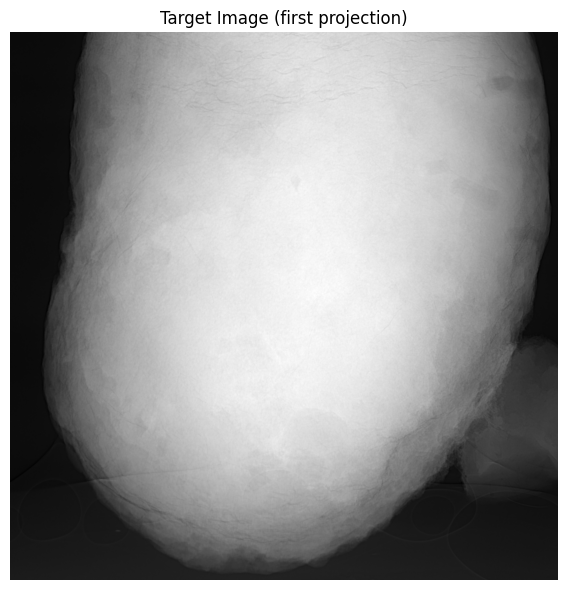

In [3]:
# ── Load dataset ──────────────────────────────────────────────────────────
DATA_PATH = Path('/myhome/data/sdate/shared/compression_paper/file_1_extracted')
NUM_PROJECTIONS = 50
TARGET_SIZE = 1024

dataset = ProjectionSliceDataset(
    folder_path=DATA_PATH,
    num_projections=NUM_PROJECTIONS,
    target_size=TARGET_SIZE,
    normalize_values=True,
    verbose=True,
    cache_volume=True,
    use_attenuation=True,
)

# Extract the first projection as the target 2D image
volume = dataset.get_full_volume()  # (H, W, D)
image_gray = volume[:, :, 0].clone()

# Normalise to [0, 1]
img_min, img_max = image_gray.min(), image_gray.max()
image_gray = (image_gray - img_min) / (img_max - img_min + 1e-8)

H, W = image_gray.shape
print(f"\nTarget image: ({H}, {W})")
print(f"Range: [{image_gray.min():.4f}, {image_gray.max():.4f}]")

# Convert grayscale → RGB (H, W, 3) for gsplat
gt_image = image_gray.unsqueeze(-1).repeat(1, 1, 3).to(device)
print(f"GT image tensor: {gt_image.shape} on {gt_image.device}")

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(image_gray.cpu().numpy(), cmap='gray', vmin=0, vmax=1)
ax.set_title('Target Image (first projection)')
ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Camera Setup (Orthographic)

Orthographic projection means no perspective distortion — rays are parallel to the z-axis.
The intrinsic matrix $K$ maps camera-space coordinates directly to pixel coordinates:

$$u = f_x \cdot x_{\text{cam}} + c_x, \quad v = f_y \cdot y_{\text{cam}} + c_y$$

We set $f_x = f_y = 1$ and $c_x = c_y = 0$, so Gaussian means in world space
are directly in pixel coordinates. The view matrix is identity, placing the camera
at the origin looking down $+z$.

In [4]:
# ── Orthographic camera (from library) ────────────────────────────────────
K, viewmat = ortho_camera(device)

print(f"Camera model: orthographic")
print(f"K (intrinsics):\n{K}")
print(f"View matrix: identity")
print(f"Image size: {W} × {H}")

Camera model: orthographic
K (intrinsics):
tensor[3, 3] n=9 x∈[0., 1.000] μ=0.333 σ=0.500 cuda:0 [[1.000, 0., 0.], [0., 1.000, 0.], [0., 0., 1.000]]
View matrix: identity
Image size: 1024 × 1024


## 4. Initialize Gaussian Parameters

Each Gaussian has:
- **means** $(x, y, z)$: $(x, y)$ in pixel space, $z$ is latent depth for compositing
- **quats** $(w, x, y, z)$: rotation quaternion
- **scales** $(s_x, s_y, s_z)$: log-space scale factors
- **rgbs**: sigmoid-space intensities (single scalar replicated to 3 channels)
- **opacities**: sigmoid-space opacity

Two initialization modes are available via `INIT_MODE`:

| Mode | Placement | Initial scale | Best for |
|------|-----------|---------------|----------|
| `'uniform'` | Regular grid (rounded to perfect square) | `INIT_SCALE_PX` | uniform / low-contrast images |
| `'intensity'` | Sampled ∝ image intensity + sub-pixel jitter | `INIT_SCALE_PX × 0.5` | images with strong bright regions; concentrates budget where signal is |


In [5]:
# ── Configuration ─────────────────────────────────────────────────────────
N_POINTS = 50_000
INIT_MODE = 'intensity'
USE_FP16 = True

# Initialise Gaussians using the library
params = init_gaussians(
    image_gray, N_POINTS, device,
    mode=INIT_MODE, init_scale_px=3.0, init_opacity=0.3, seed=42,
)

print(f"Init mode:  {INIT_MODE}")
print(f"Gaussians:  {params.n_gaussians:,}")
print(f"Parameters: {params.param_count():,} ({params.param_count() * 4 / 1e6:.2f} MB)")
print(f"  means:      {params.means.shape}")
print(f"  log_scales: {params.log_scales.shape}")
print(f"  quats:      {params.quats.shape}")
print(f"  rgbs:       {params.rgbs.shape}")
print(f"  opacities:  {params.opacities.shape}")

Init mode:  intensity
Gaussians:  50,000
Parameters: 700,000 (2.80 MB)
  means:      torch.Size([50000, 3])
  log_scales: torch.Size([50000, 3])
  quats:      torch.Size([50000, 4])
  rgbs:       torch.Size([50000, 3])
  opacities:  torch.Size([50000])


## 5. Rendering Function

A thin wrapper around `gsplat.rasterization()` that applies activations
and calls the full pipeline (projection → tile binning → compositing).

Test render: torch.Size([1024, 1024, 3]), range [0.0000, 0.9405]
Alpha: torch.Size([1024, 1024, 1]), range [0.0000, 0.9840]


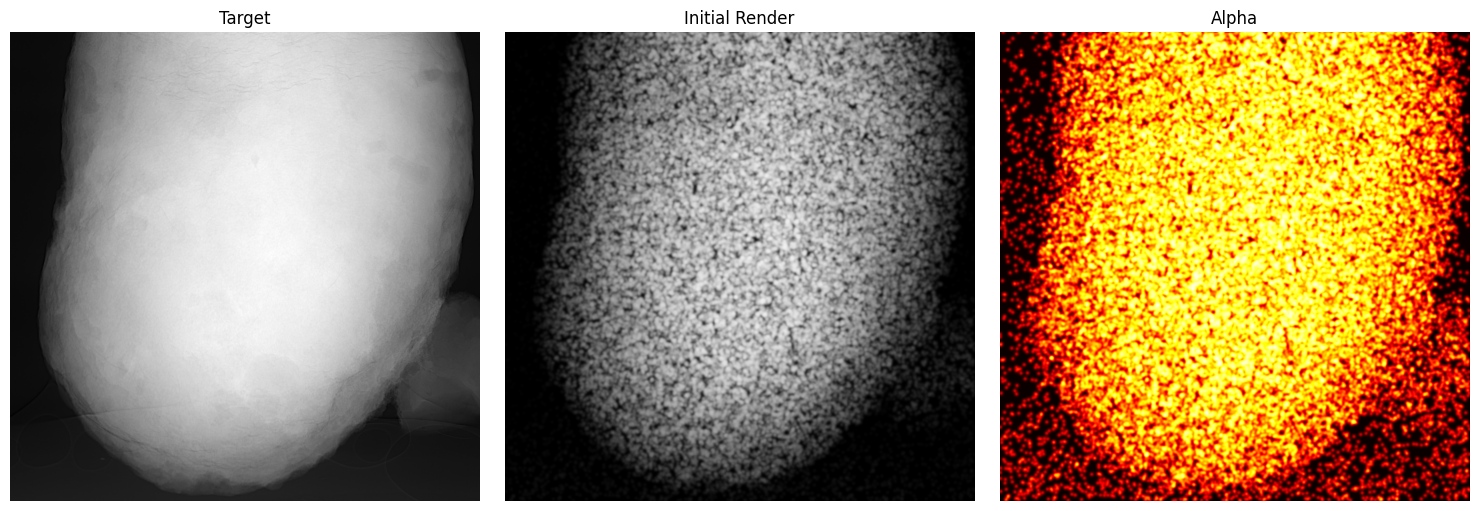

In [6]:
# ── Rendering function is now in the library: gsplat_compress.render() ────

# Quick test render
with torch.no_grad():
    test_render, test_alpha, _ = render(
        params.means, params.log_scales, params.quats,
        params.rgbs, params.opacities, viewmat, K, W, H,
    )
    print(f"Test render: {test_render.shape}, range [{test_render.min():.4f}, {test_render.max():.4f}]")
    print(f"Alpha: {test_alpha.shape}, range [{test_alpha.min():.4f}, {test_alpha.max():.4f}]")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(gt_image[:, :, 0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Target'); axes[0].axis('off')
axes[1].imshow(test_render[:, :, 0].detach().cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Initial Render'); axes[1].axis('off')
axes[2].imshow(test_alpha[:, :, 0].detach().cpu().numpy(), cmap='hot', vmin=0, vmax=1)
axes[2].set_title('Alpha'); axes[2].axis('off')
plt.tight_layout()
plt.show()

## 6. Training Loop

Optimise all Gaussian parameters with Adam, using MSE loss between rendered and target image.
The full gsplat pipeline runs each iteration: projection → tile binning → compositing → loss → backprop.

**Adaptive control** is interleaved inside the loop every `DENSIFY_INTERVAL` iterations (between `DENSIFY_FROM` and `DENSIFY_UNTIL`):
- **Pruning** — remove Gaussians whose sigmoid-opacity falls below `PRUNE_OPACITY_THRESH`
- **Densification** — split Gaussians whose max xy-scale exceeds `SPLIT_SCALE_THRESH` into two children with half the scale
- The optimizer is rebuilt after each event to track the new tensor references
- Learning rates are halved once training passes the halfway point


In [7]:
# ── Training configuration (from library) ─────────────────────────────────
train_cfg = TrainConfig(
    num_iterations=15000,
    use_fp16=USE_FP16,
    log_interval=100,
    lr_means=1e-3,
    lr_scales=5e-3,
    lr_quats=1e-3,
    lr_rgbs=1e-2,
    lr_opacities=5e-2,
    densify_from=500,
    densify_interval=500,
    densify_until=12000,
    prune_opacity_thresh=0.005,
    split_scale_thresh=10.0,
)
print(f"Training config: {train_cfg}")

Training config: TrainConfig(num_iterations=15000, use_fp16=True, log_interval=100, lr_means=0.001, lr_scales=0.005, lr_quats=0.001, lr_rgbs=0.01, lr_opacities=0.05, densify_from=500, densify_interval=500, densify_until=12000, prune_opacity_thresh=0.005, split_scale_thresh=10.0)


In [8]:
# ── Keyframe training (library call) ──────────────────────────────────────
train_result = train_keyframe(params, gt_image, viewmat, K, W, H, train_cfg, verbose=True)

# Unpack for downstream cells
params = train_result.params
loss_history = train_result.loss_history
psnr_history = train_result.psnr_history
densify_iters = train_result.densify_iters
elapsed = train_result.elapsed

# Backward-compat aliases
all_losses = loss_history
all_psnrs = psnr_history

Training keyframe: 15000 iters, N=50,000, fp16=True
[    0/15000]  loss=0.049360  PSNR=13.07 dB  N=50,000
[  100/15000]  loss=0.000567  PSNR=32.47 dB  N=50,000
[  200/15000]  loss=0.000188  PSNR=37.26 dB  N=50,000
[  300/15000]  loss=0.000122  PSNR=39.15 dB  N=50,000
[  400/15000]  loss=0.000098  PSNR=40.10 dB  N=50,000
[  500/15000]  loss=0.000085  PSNR=40.69 dB  N=50,000
  ↳ [densify @ 500]  pruned=0  split=248  N=50,248
[  600/15000]  loss=0.000061  PSNR=42.14 dB  N=50,248
[  700/15000]  loss=0.000054  PSNR=42.68 dB  N=50,248
[  800/15000]  loss=0.000050  PSNR=43.01 dB  N=50,248
[  900/15000]  loss=0.000047  PSNR=43.26 dB  N=50,248
[ 1000/15000]  loss=0.000045  PSNR=43.46 dB  N=50,248
  ↳ [densify @ 1000]  pruned=0  split=692  N=50,940
[ 1100/15000]  loss=0.000046  PSNR=43.40 dB  N=50,940
[ 1200/15000]  loss=0.000043  PSNR=43.69 dB  N=50,940
[ 1300/15000]  loss=0.000041  PSNR=43.87 dB  N=50,940
[ 1400/15000]  loss=0.000040  PSNR=44.02 dB  N=50,940
[ 1500/15000]  loss=0.000039  PSNR=

## 7. Visualization

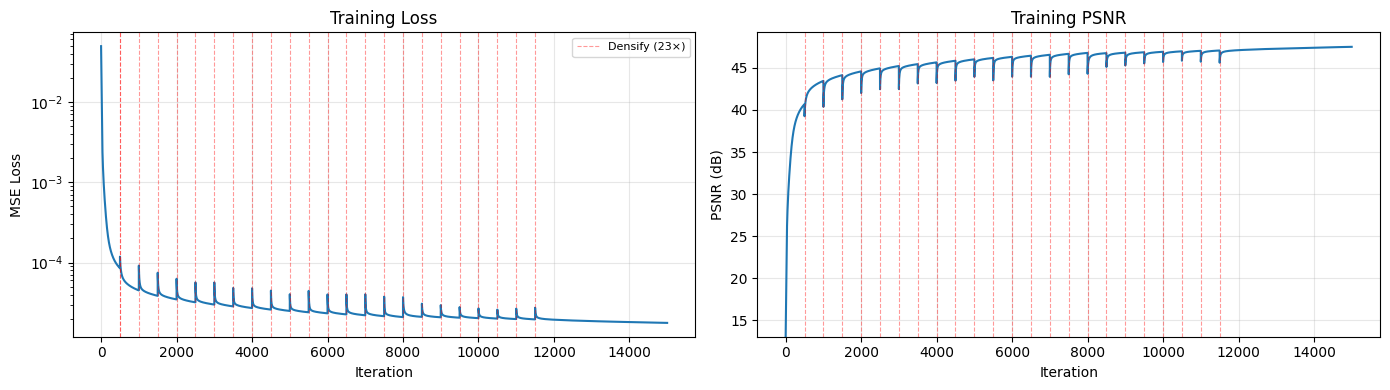

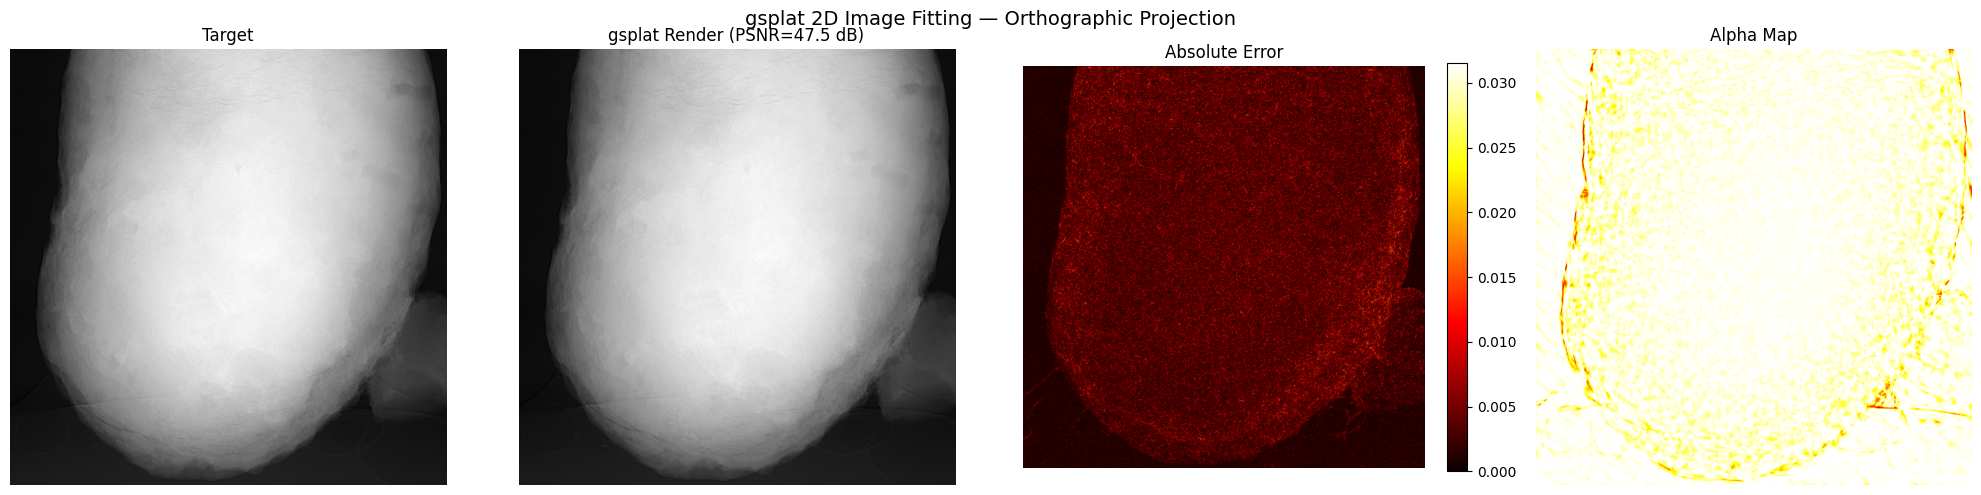

In [9]:
# ── Final render ──────────────────────────────────────────────────────────
with torch.no_grad():
    final_render, final_alpha, _ = render(
        params.means, params.log_scales, params.quats,
        params.rgbs, params.opacities, viewmat, K, W, H,
    )

final_np = final_render[:, :, 0].cpu().numpy()
target_np = gt_image[:, :, 0].cpu().numpy()
alpha_np  = final_alpha[:, :, 0].cpu().numpy()
error_np  = np.abs(final_np - target_np)

# ── Loss & PSNR curves ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].semilogy(loss_history)
for di in densify_iters:
    axes[0].axvline(x=di, color='r', linestyle='--', alpha=0.4, linewidth=0.8)
if densify_iters:
    axes[0].axvline(x=densify_iters[0], color='r', linestyle='--', alpha=0.4,
                    linewidth=0.8, label=f'Densify ({len(densify_iters)}×)')
    axes[0].legend(fontsize=8)
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training Loss'); axes[0].grid(True, alpha=0.3)

axes[1].plot(psnr_history)
for di in densify_iters:
    axes[1].axvline(x=di, color='r', linestyle='--', alpha=0.4, linewidth=0.8)
axes[1].set_ylim(bottom=min(psnr_history[:100]) if psnr_history else 0)
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('PSNR (dB)')
axes[1].set_title('Training PSNR'); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── Side-by-side comparison ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(target_np, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Target'); axes[0].axis('off')
axes[1].imshow(np.clip(final_np, 0, 1), cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'gsplat Render (PSNR={psnr_history[-1]:.1f} dB)'); axes[1].axis('off')
im = axes[2].imshow(error_np, cmap='hot')
axes[2].set_title('Absolute Error'); axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046)
axes[3].imshow(alpha_np, cmap='hot', vmin=0, vmax=1)
axes[3].set_title('Alpha Map'); axes[3].axis('off')
plt.suptitle('gsplat 2D Image Fitting — Orthographic Projection', fontsize=14)
plt.tight_layout(); plt.show()

## 8. Metrics & Compression Summary

In [10]:
# (placeholder — metrics computed below)

In [11]:
# ── Metrics (using library functions) ──────────────────────────────────────
final_psnr_val = psnr(np.clip(final_np, 0, 1), target_np)
final_ssim_val = ssim(np.clip(final_np, 0, 1), target_np)
final_mse_val  = mse(np.clip(final_np, 0, 1), target_np)

n_active = params.n_gaussians
model_bytes = keyframe_bytes(n_active, USE_FP16)
original_bytes = raw_frame_bytes(H, W)
cr = compression_ratio(model_bytes, H, W)

print(f"{'='*50}")
print(f"IMAGE FITTING METRICS (gsplat ortho)")
print(f"{'='*50}")
print(f"  MSE:               {final_mse_val:.6f}")
print(f"  PSNR:              {final_psnr_val:.2f} dB")
print(f"  SSIM:              {final_ssim_val:.4f}")
print(f"  Gaussians:         {n_active:,}")
print(f"  Params/Gaussian:   {PARAMS_PER_GAUSSIAN_EFF} (non-redundant)")
print(f"  Model size:        {model_bytes / 1e6:.2f} MB")
print(f"  Original size:     {original_bytes / 1e6:.2f} MB (int16)")
print(f"  Compression ratio: {cr:.2f}×")
print(f"  Training time:     {elapsed:.1f}s")

IMAGE FITTING METRICS (gsplat ortho)
  MSE:               0.000018
  PSNR:              47.50 dB
  SSIM:              0.9838
  Gaussians:         62,379
  Params/Gaussian:   9 (non-redundant)
  Model size:        1.12 MB
  Original size:     2.10 MB (int16)
  Compression ratio: 1.87×
  Training time:     58.0s


## 8b. Parameter Redundancy Analysis (3D Gaussians for 2D Fitting)

For orthographic 2D image fitting, several parameters of the full 3D Gaussian representation are redundant.
This cell quantifies exactly which ones and computes the storage savings.

In [12]:
N = params.n_gaussians

# ── Parameter redundancy analysis (using library constants) ──────────────
print("=" * 60)
print("  PARAMETER REDUNDANCY ANALYSIS")
print("=" * 60)
print(f"  Full stored params/Gaussian  : {PARAMS_PER_GAUSSIAN_FULL}")
print(f"  Non-redundant params/Gaussian: {PARAMS_PER_GAUSSIAN_EFF}")
print(f"  Redundant params/Gaussian    : {PARAMS_PER_GAUSSIAN_FULL - PARAMS_PER_GAUSSIAN_EFF}")
print(f"  Reduction                    : {100*(PARAMS_PER_GAUSSIAN_FULL - PARAMS_PER_GAUSSIAN_EFF)/PARAMS_PER_GAUSSIAN_FULL:.1f}%")
print()
print(f"  For deltas:")
print(f"    Full delta dims : {D_FULL}")
print(f"    Effective dims  : {D_EFF}")
print(f"    Redundant dims  : {D_FULL - D_EFF}")
print()

bytes_per_float = 2 if USE_FP16 else 4
current_bytes = N * PARAMS_PER_GAUSSIAN_FULL * bytes_per_float
minimal_bytes = N * PARAMS_PER_GAUSSIAN_EFF  * bytes_per_float
saved_bytes   = current_bytes - minimal_bytes

print("=" * 60)
print("  STORAGE SAVINGS")
print("=" * 60)
print(f"  Active Gaussians          : {N:>10,}")
print(f"  Current storage  : {current_bytes/1e6:>8.2f} MB")
print(f"  Minimal storage  : {minimal_bytes/1e6:>8.2f} MB")
print(f"  Savings          : {saved_bytes/1e6:>8.2f} MB")
print(f"  Reduction        : {100*saved_bytes/current_bytes:.1f}%")
print("=" * 60)
print(f"\n  Original image: {H*W*2/1e6:.2f} MB (int16, {W}×{H})")
print(f"  Compression ratio (minimal): {H*W*2 / minimal_bytes:.2f}×")

  PARAMETER REDUNDANCY ANALYSIS
  Full stored params/Gaussian  : 14
  Non-redundant params/Gaussian: 9
  Redundant params/Gaussian    : 5
  Reduction                    : 35.7%

  For deltas:
    Full delta dims : 14
    Effective dims  : 8
    Redundant dims  : 6

  STORAGE SAVINGS
  Active Gaussians          :     62,379
  Current storage  :     1.75 MB
  Minimal storage  :     1.12 MB
  Savings          :     0.62 MB
  Reduction        : 35.7%

  Original image: 2.10 MB (int16, 1024×1024)
  Compression ratio (minimal): 1.87×


## 8c. Parameter Quantization to 16-bit and 8-bit

How much quality is lost by storing the Gaussian parameters at reduced precision?

**Protocol (frame 1 reconstruction):**
- Take the fitted parameters from `snap1_*` (float32 reference)
- **float16**: cast each tensor to `torch.float16`, then back to `torch.float32` — simulates IEEE half-precision storage
- **int8**: per-parameter affine quantization — map the float32 range $[v_{min}, v_{max}]$ to $[0, 255]$, round to integer, then map back — simulates 8-bit fixed-point storage
- Rasterize each quantized version and compare to float32 reference

**Storage impact** (for the 9 non-redundant parameters per Gaussian):
| Precision | Bytes/value | Total (100K Gaussians × 9 params) | vs float32 |
|---|---|---|---|
| float32 | 4 | ~3.6 MB | — |
| float16 | 2 | ~1.8 MB | −50% |
| int8 | 1 | ~0.9 MB | −75% |

In [13]:
# from skimage.metrics import structural_similarity as ssim

# # ── Helper: int8 affine quantization (per-tensor) ────────────────────────
# def quantize_int8(t: torch.Tensor) -> torch.Tensor:
#     """Quantize float32 tensor to int8 range [0,255] and back to float32."""
#     t_min = t.min()
#     t_max = t.max()
#     scale = (t_max - t_min) / 255.0
#     if scale == 0:          # constant tensor
#         return t.clone()
#     q = torch.clamp(torch.round((t - t_min) / scale), 0, 255).to(torch.uint8)
#     return q.float() * scale + t_min

# def quantize_fp16(t: torch.Tensor) -> torch.Tensor:
#     """Quantize float32 tensor to float16 and back to float32."""
#     return t.to(torch.float16).to(torch.float32)

# # ── Parameters for frame 1 (reference = snap1_*, float32) ────────────────
# # Use snap1_* if available (set in section 11), else fall back to current means/…
# if 'snap1_means' in dir():
#     p1_means      = snap1_means
#     p1_log_scales = snap1_log_scales
#     p1_quats      = snap1_quats
#     p1_rgbs       = snap1_rgbs
#     p1_opacities  = snap1_opacities
# else:
#     p1_means      = means.detach()
#     p1_log_scales = log_scales.detach()
#     p1_quats      = quats.detach()
#     p1_rgbs       = rgbs.detach()
#     p1_opacities  = opacities.detach()

# # Reference float32 render
# with torch.no_grad():
#     rend_f32, _, _ = render(p1_means, p1_log_scales, p1_quats,
#                              p1_rgbs, p1_opacities, viewmat, K, W, H)
# np_f32    = np.clip(rend_f32[:,:,0].cpu().numpy(), 0, 1)
# np_target = gt_image[:,:,0].cpu().numpy()      # frame-1 target

# psnr_f32 = -10*np.log10(np.mean((np_f32 - np_target)**2) + 1e-10)
# ssim_f32 = ssim(np_target, np_f32, data_range=1.0)

# N_Q = p1_means.shape[0]     # number of Gaussians
# # Non-redundant params per Gaussian (from section 8b): 9
# #   means(3) + log_scales(2) + angle(2) + rgb_scalar(1) + opacity(1)
# # For storage comparison we use all 14 stored floats (as-is in snap1_*)
# # and separately the minimal 9.
# n_stored   = 3 + 3 + 4 + 3 + 1    # 14 actually stored floats per Gaussian
# n_minimal  = 3 + 2 + 2 + 1 + 1    # 9 truly needed floats per Gaussian
# orig_bytes = H * W * 2              # int16 original frame

# print(f"Frame 1 reconstruction:  {N_Q:,} Gaussians")
# print(f"  float32 reference:  PSNR={psnr_f32:.2f} dB  SSIM={ssim_f32:.4f}")
# print()

# # ── Quantize each parameter group and render ─────────────────────────────
# schemes = {
#     'float32 (reference)': lambda t: t,
#     'float16':             quantize_fp16,
#     'int8':                quantize_int8,
# }

# rows_q = []   # (label, psnr, ssim, render_np, bytes_stored, bytes_minimal)

# for label, qfn in schemes.items():
#     q_means      = qfn(p1_means.cpu()).to(device)
#     q_log_scales = qfn(p1_log_scales.cpu()).to(device)
#     q_quats      = qfn(p1_quats.cpu()).to(device)
#     q_rgbs       = qfn(p1_rgbs.cpu()).to(device)
#     q_opacities  = qfn(p1_opacities.cpu()).to(device)

#     with torch.no_grad():
#         rend_q, _, _ = render(q_means, q_log_scales, q_quats,
#                                q_rgbs, q_opacities, viewmat, K, W, H)

#     np_q = np.clip(rend_q[:,:,0].cpu().numpy(), 0, 1)
#     p = -10*np.log10(np.mean((np_q - np_target)**2) + 1e-10)
#     s = ssim(np_target, np_q, data_range=1.0)

#     bpv = {'float32 (reference)': 4, 'float16': 2, 'int8': 1}[label]
#     b_stored  = N_Q * n_stored  * bpv
#     b_minimal = N_Q * n_minimal * bpv

#     rows_q.append((label, p, s, np_q, b_stored, b_minimal))

# # ── Print table ───────────────────────────────────────────────────────────
# print(f"  {'Precision':<22} {'PSNR':>8} {'ΔPSNR':>7} {'SSIM':>7}"
#       f" {'All-14 MB':>10} {'Min-9 MB':>9} {'CR vs orig':>11}")
# print("-" * 80)
# for label, p, s, _, b_st, b_mn in rows_q:
#     dp  = p - psnr_f32
#     cr  = orig_bytes / b_mn
#     print(f"  {label:<22} {p:>8.2f} {dp:>+7.2f} {s:>7.4f}"
#           f" {b_st/1e6:>10.2f} {b_mn/1e6:>9.2f} {cr:>10.2f}×")

# print()
# print(f"  Original frame (int16): {orig_bytes/1e6:.2f} MB")

# # ── Visualisation ─────────────────────────────────────────────────────────
# fig, axes = plt.subplots(2, len(rows_q) + 1, figsize=(5*(len(rows_q)+1), 9))

# def _show(ax, img, title, cmap='gray', vmin=0, vmax=1):
#     ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
#     ax.set_title(title, fontsize=9);  ax.axis('off')

# # Column 0: target
# _show(axes[0, 0], np_target, 'Target (frame 1)')
# _show(axes[1, 0], np.zeros_like(np_target), 'error = 0', cmap='hot', vmax=0.05)

# for j, (label, p, s, np_q, b_st, b_mn) in enumerate(rows_q):
#     err = np.abs(np_q - np_target)
#     _show(axes[0, j+1], np_q,
#           f'{label}\n{p:.2f} dB / SSIM={s:.4f}\n{b_mn/1e6:.2f} MB (min params)')
#     _show(axes[1, j+1], err,
#           f'|error|  max={err.max():.4f}', cmap='hot', vmin=0, vmax=0.05)

# plt.suptitle('Effect of Parameter Quantization on Frame 1 Reconstruction\n'
#              '(storage size shown for the 9 non-redundant parameters)',
#              fontsize=12)
# plt.tight_layout()
# plt.show()

# # ── Per-parameter quantization error ─────────────────────────────────────
# param_groups = {
#     'means':      (p1_means,      'float32 (reference)'),
#     'log_scales': (p1_log_scales, 'float32 (reference)'),
#     'quats':      (p1_quats,      'float32 (reference)'),
#     'rgbs':       (p1_rgbs,       'float32 (reference)'),
#     'opacities':  (p1_opacities.unsqueeze(-1), 'float32 (reference)'),
# }

# print("\nPer-parameter quantization error (RMSE):")
# print(f"  {'Param':<14} {'fp16 RMSE':>12} {'int8 RMSE':>12} {'fp16 max':>12} {'int8 max':>12}")
# print("-" * 66)
# for pname, (pt, _) in param_groups.items():
#     q16 = quantize_fp16(pt.cpu());  q8 = quantize_int8(pt.cpu())
#     rmse16 = (pt.cpu() - q16).pow(2).mean().sqrt().item()
#     rmse8  = (pt.cpu() - q8 ).pow(2).mean().sqrt().item()
#     max16  = (pt.cpu() - q16).abs().max().item()
#     max8   = (pt.cpu() - q8 ).abs().max().item()
#     print(f"  {pname:<14} {rmse16:>12.6f} {rmse8:>12.6f} {max16:>12.6f} {max8:>12.6f}")


## 9. Final Comparison


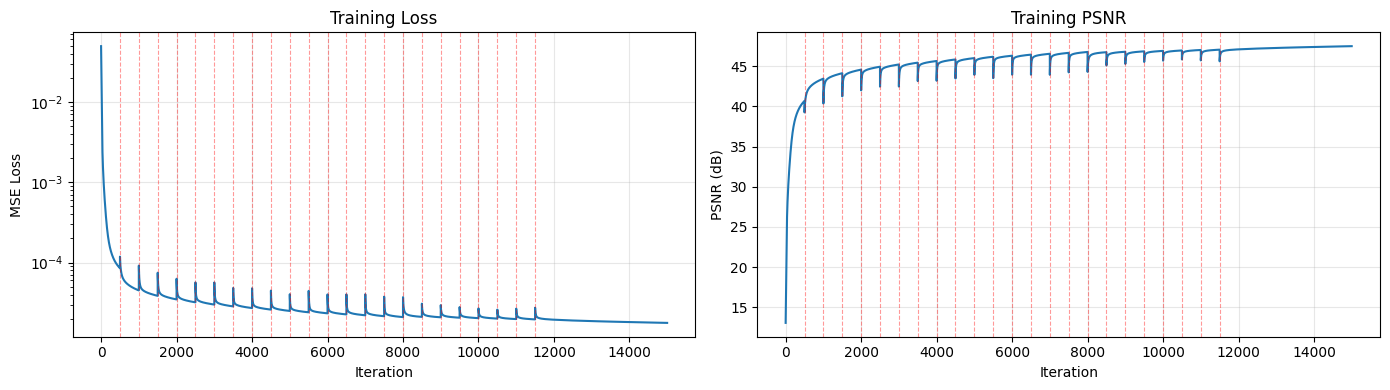

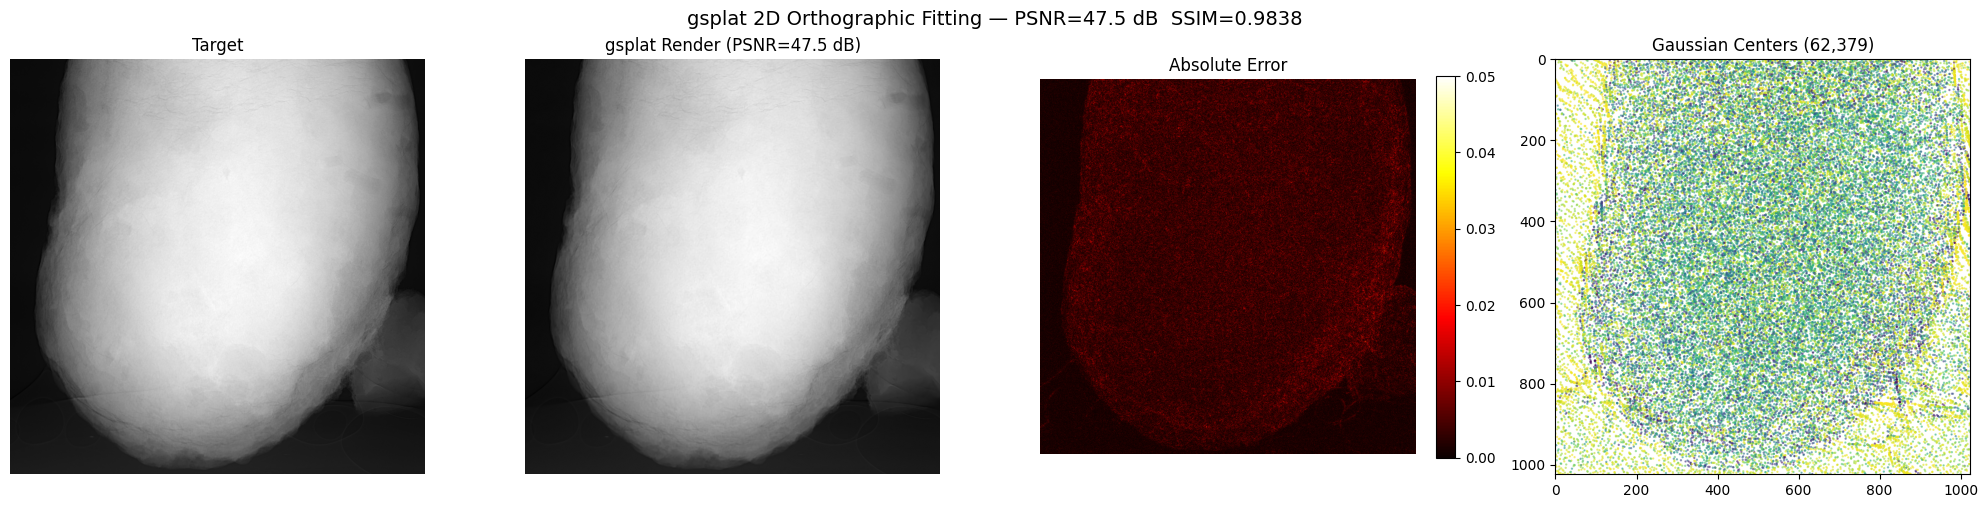


FINAL RESULTS
  PSNR:              47.50 dB
  SSIM:              0.9838
  Gaussians:         62,379
  Model size:        1.12 MB
  Compression ratio: 1.87×
  Total time:        58.0s


In [14]:
# ── Final render and summary ───────────────────────────────────────────────
with torch.no_grad():
    final_render_p2, final_alpha_p2, _ = render(
        params.means, params.log_scales, params.quats,
        params.rgbs, params.opacities, viewmat, K, W, H,
    )

final_np_p2  = np.clip(final_render_p2[:, :, 0].cpu().numpy(), 0, 1)
error_np_p2  = np.abs(final_np_p2 - target_np)
final_psnr_p2 = psnr(final_np_p2, target_np)
final_ssim_p2 = ssim(final_np_p2, target_np)

# ── Loss & PSNR curves ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].semilogy(all_losses)
for di in densify_iters:
    axes[0].axvline(x=di, color='r', linestyle='--', alpha=0.4, linewidth=0.8)
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Training Loss'); axes[0].grid(True, alpha=0.3)
axes[1].plot(all_psnrs)
for di in densify_iters:
    axes[1].axvline(x=di, color='r', linestyle='--', alpha=0.4, linewidth=0.8)
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('PSNR (dB)')
axes[1].set_title('Training PSNR'); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── Side-by-side ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(target_np, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Target'); axes[0].axis('off')
axes[1].imshow(final_np_p2, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'gsplat Render (PSNR={final_psnr_p2:.1f} dB)'); axes[1].axis('off')
im = axes[2].imshow(error_np_p2, cmap='hot', vmin=0, vmax=0.05)
axes[2].set_title('Absolute Error'); axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046)

means_np = params.means.detach().cpu().numpy()
opac_np  = torch.sigmoid(params.opacities).detach().cpu().numpy()
n_show   = min(50000, means_np.shape[0])
idx_show = np.random.choice(means_np.shape[0], n_show, replace=False)
axes[3].scatter(means_np[idx_show, 0], means_np[idx_show, 1],
                c=opac_np[idx_show], cmap='viridis', s=0.5, alpha=0.5)
axes[3].set_xlim(0, W); axes[3].set_ylim(H, 0)
axes[3].set_title(f'Gaussian Centers ({params.n_gaussians:,})'); axes[3].set_aspect('equal')
plt.suptitle(f'gsplat 2D Orthographic Fitting — PSNR={final_psnr_p2:.1f} dB  '
             f'SSIM={final_ssim_p2:.4f}', fontsize=14)
plt.tight_layout(); plt.show()

# ── Summary ───────────────────────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"FINAL RESULTS")
print(f"{'='*50}")
print(f"  PSNR:              {final_psnr_p2:.2f} dB")
print(f"  SSIM:              {final_ssim_p2:.4f}")
print(f"  Gaussians:         {params.n_gaussians:,}")
print(f"  Model size:        {keyframe_bytes(params.n_gaussians, USE_FP16) / 1e6:.2f} MB")
print(f"  Compression ratio: {compression_ratio(keyframe_bytes(params.n_gaussians, USE_FP16), H, W):.2f}×")
print(f"  Total time:        {elapsed:.1f}s")

## 11. Inter-Frame Delta Compression (Image 1 → Image 2)

**Idea:** The two projections are very similar. Instead of fitting image 2 from scratch,
we fine-tune the image-1 Gaussians to image 2. The resulting **per-Gaussian parameter deltas**
$\Delta_i = \theta_i^{(2)} - \theta_i^{(1)}$ should be small and clustered.

**Pipeline:**
1. **Snapshot** the image-1 fit (`means₁, log_scales₁, quats₁, rgbs₁, opacities₁`)
2. **Fine-tune** to image 2 → produce `means₂, …`
3. **Compute deltas** ∈ ℝ^{N×14}
4. **K-means** over the delta vectors — elbow rule to choose K
5. **Quantize**: replace each Gaussian's delta with its cluster centroid
6. **Reconstruct** image-1 params + quantized delta → rasterize → compare error vs. K

Snapshot of image-1 fit saved: 62,379 Gaussians

Image 2 — shape torch.Size([1024, 1024]), range [0.0000, 1.0000]


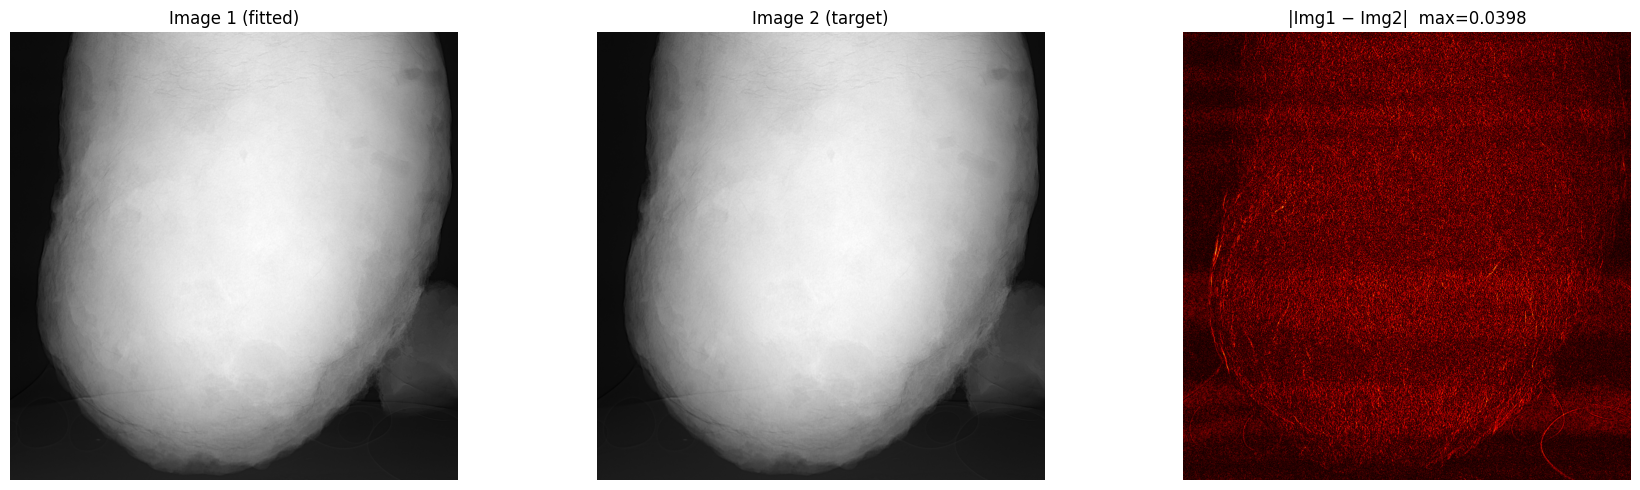

In [15]:
# ── 11.1  Snapshot the image-1 fitted parameters ─────────────────────────
snap1 = params.detach_clone()
N_SNAP = snap1.n_gaussians
print(f"Snapshot of image-1 fit saved: {N_SNAP:,} Gaussians")

# ── 11.2  Load second projection as new target ────────────────────────────
image_gray2 = volume[:, :, 1].clone()
img_min2, img_max2 = image_gray2.min(), image_gray2.max()
image_gray2 = (image_gray2 - img_min2) / (img_max2 - img_min2 + 1e-8)
gt_image2 = image_gray2.unsqueeze(-1).repeat(1, 1, 3).to(device)
print(f"\nImage 2 — shape {image_gray2.shape}, "
      f"range [{image_gray2.min():.4f}, {image_gray2.max():.4f}]")

# Visual side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(image_gray.cpu().numpy(),  cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Image 1 (fitted)');   axes[0].axis('off')
axes[1].imshow(image_gray2.cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[1].set_title('Image 2 (target)');   axes[1].axis('off')
diff_np = np.abs(image_gray.cpu().numpy() - image_gray2.cpu().numpy())
axes[2].imshow(diff_np, cmap='hot', vmin=0, vmax=diff_np.max())
axes[2].set_title(f'|Img1 − Img2|  max={diff_np.max():.4f}')
axes[2].axis('off')
plt.tight_layout(); plt.show()

Fine-tuning frame: 10000 iters, N=62,379, lr_scale=0.3
  [    0/10000]  loss=0.000038  PSNR=44.17 dB
  [  200/10000]  loss=0.000024  PSNR=46.19 dB
  [  400/10000]  loss=0.000023  PSNR=46.34 dB
  [  600/10000]  loss=0.000023  PSNR=46.44 dB
  [  800/10000]  loss=0.000022  PSNR=46.50 dB
  [ 1000/10000]  loss=0.000022  PSNR=46.56 dB
  [ 1200/10000]  loss=0.000022  PSNR=46.60 dB
  [ 1400/10000]  loss=0.000022  PSNR=46.64 dB
  [ 1600/10000]  loss=0.000021  PSNR=46.68 dB
  [ 1800/10000]  loss=0.000021  PSNR=46.71 dB
  [ 2000/10000]  loss=0.000021  PSNR=46.74 dB
  [ 2200/10000]  loss=0.000021  PSNR=46.76 dB
  [ 2400/10000]  loss=0.000021  PSNR=46.79 dB
  [ 2600/10000]  loss=0.000021  PSNR=46.81 dB
  [ 2800/10000]  loss=0.000021  PSNR=46.83 dB
  [ 3000/10000]  loss=0.000021  PSNR=46.85 dB
  [ 3200/10000]  loss=0.000021  PSNR=46.88 dB
  [ 3400/10000]  loss=0.000020  PSNR=46.89 dB
  [ 3600/10000]  loss=0.000020  PSNR=46.91 dB
  [ 3800/10000]  loss=0.000020  PSNR=46.93 dB
  [ 4000/10000]  loss=0.0

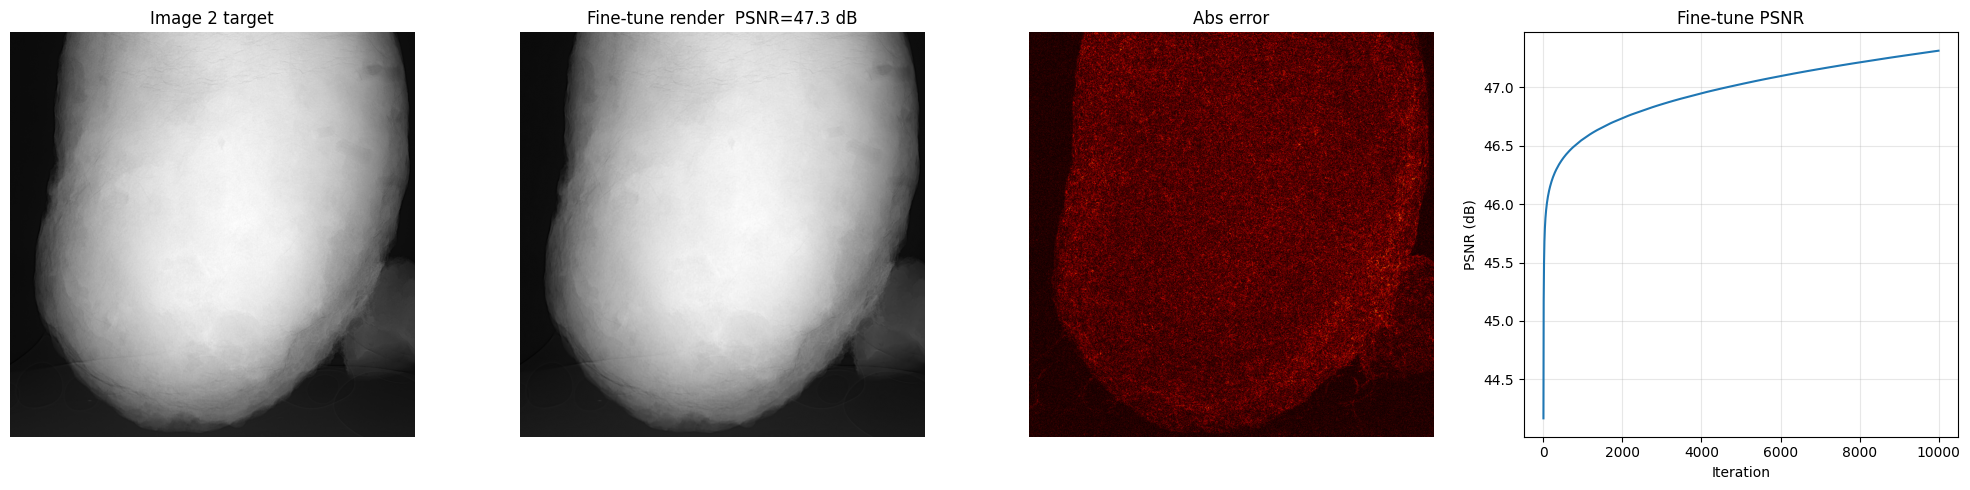

In [16]:
# ── 11.3  Fine-tune the snapshot Gaussians to image 2 (library call) ─────
ft_cfg = FinetuneConfig(
    num_iterations=10000,
    use_fp16=USE_FP16,
    log_interval=200,
    lr_scale=0.3,
)

ft_result = finetune_frame(snap1, gt_image2, viewmat, K, W, H, ft_cfg, verbose=True)

# snap2 = fine-tuned params for image 2
snap2 = ft_result.params.detach_clone()
ft_loss_history = ft_result.loss_history
ft_psnr_history = ft_result.psnr_history
elapsed_ft = ft_result.elapsed

# Quick visual
with torch.no_grad():
    render_ft2, _, _ = render(snap2.means, snap2.log_scales, snap2.quats,
                               snap2.rgbs, snap2.opacities, viewmat, K, W, H)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(image_gray2.cpu().numpy(),       cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Image 2 target');            axes[0].axis('off')
axes[1].imshow(render_ft2[:,:,0].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'Fine-tune render  PSNR={ft_psnr_history[-1]:.1f} dB')
axes[1].axis('off')
err_ft = np.abs(render_ft2[:,:,0].cpu().numpy() - image_gray2.cpu().numpy())
axes[2].imshow(err_ft, cmap='hot')
axes[2].set_title('Abs error'); axes[2].axis('off')
axes[3].plot(ft_psnr_history)
axes[3].set_xlabel('Iteration'); axes[3].set_ylabel('PSNR (dB)')
axes[3].set_title('Fine-tune PSNR'); axes[3].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Delta matrix: 62,379 Gaussians × 14 parameters

  Parameter            mean        std        min        max
------------------------------------------------------------
  Δmean_x           0.00223    0.02845   -0.54749    0.52209
  Δmean_y           0.00005    0.02351   -0.47961    0.40784
  Δmean_z           0.00000    0.00000    0.00000    0.00000
  Δscale_x          0.00113    0.14369   -1.25460    0.90024
  Δscale_y          0.00451    0.13975   -0.97398    1.00553
  Δscale_z          0.00000    0.00000    0.00000    0.00000
  Δquat_w          -0.00163    0.00939   -0.13058    0.10916
  Δquat_x           0.00000    0.00000    0.00000    0.00000
  Δquat_y           0.00000    0.00000    0.00000    0.00000
  Δquat_z          -0.00007    0.04481   -0.31273    0.28870
  Δrgb_r            0.01466    0.08705   -0.62887    0.72300
  Δrgb_g            0.01466    0.08705   -0.62887    0.72300
  Δrgb_b            0.01466    0.08705   -0.62887    0.72300
  Δopacity          0.00212    0.3889

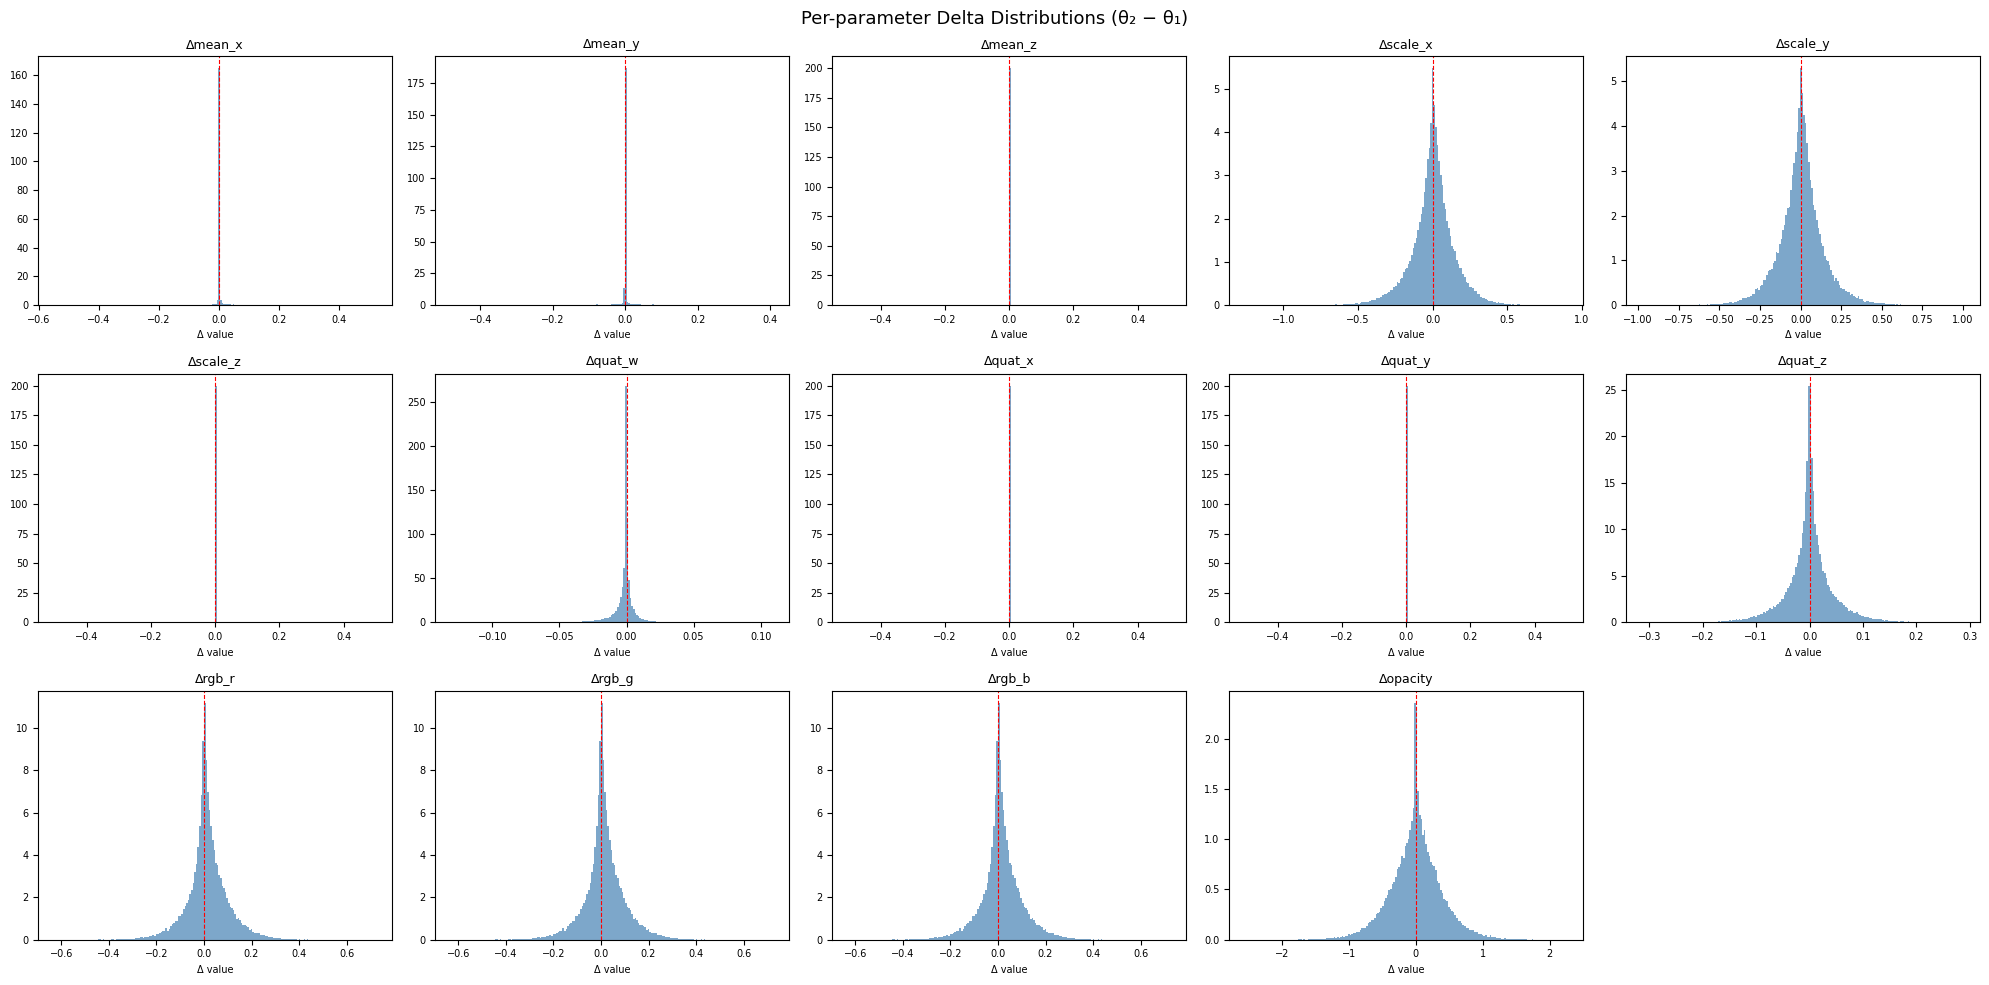


Per-Gaussian ‖Δ‖₂:  mean=0.38719  std=0.26151  max=2.63226


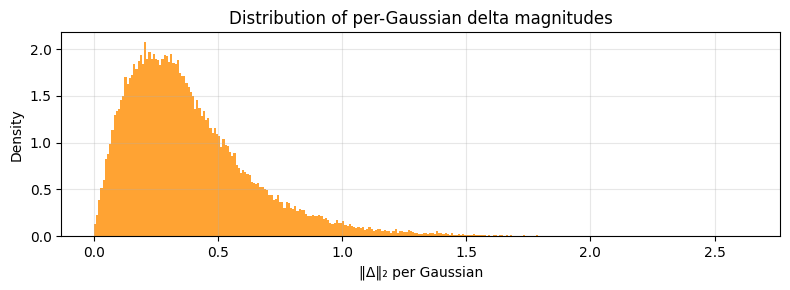

In [17]:
# ── 11.4  Compute per-Gaussian deltas (library call) ──────────────────────
delta_all = compute_deltas(snap1, snap2)   # [N, 14] numpy

param_names = (
    ['Δmean_x', 'Δmean_y', 'Δmean_z'] +
    ['Δscale_x', 'Δscale_y', 'Δscale_z'] +
    ['Δquat_w', 'Δquat_x', 'Δquat_y', 'Δquat_z'] +
    ['Δrgb_r', 'Δrgb_g', 'Δrgb_b'] +
    ['Δopacity']
)

N_G, D = delta_all.shape
print(f"Delta matrix: {N_G:,} Gaussians × {D} parameters")
print()
print(f"  {'Parameter':<14} {'mean':>10} {'std':>10} {'min':>10} {'max':>10}")
print("-" * 60)
for i, pname in enumerate(param_names):
    col = delta_all[:, i]
    print(f"  {pname:<14} {col.mean():>10.5f} {col.std():>10.5f} "
          f"{col.min():>10.5f} {col.max():>10.5f}")

# ── Per-parameter delta distributions ──────────────────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(20, 10))
axes_flat = axes.flatten()
for i, pname in enumerate(param_names):
    col = delta_all[:, i]
    axes_flat[i].hist(col, bins=200, density=True, color='steelblue', alpha=0.7)
    axes_flat[i].set_title(pname, fontsize=9)
    axes_flat[i].set_xlabel('Δ value', fontsize=7)
    axes_flat[i].tick_params(labelsize=7)
    axes_flat[i].axvline(0, color='r', linewidth=0.8, linestyle='--')
axes_flat[-1].set_visible(False)
plt.suptitle('Per-parameter Delta Distributions (θ₂ − θ₁)', fontsize=13)
plt.tight_layout(); plt.show()

# ── Per-Gaussian L2 norm ──────────────────────────────────────────────────
delta_norms = np.linalg.norm(delta_all, axis=1)
print(f"\nPer-Gaussian ‖Δ‖₂:  mean={delta_norms.mean():.5f}  "
      f"std={delta_norms.std():.5f}  max={delta_norms.max():.5f}")
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(delta_norms, bins=300, density=True, color='darkorange', alpha=0.8)
ax.set_xlabel('‖Δ‖₂ per Gaussian'); ax.set_ylabel('Density')
ax.set_title('Distribution of per-Gaussian delta magnitudes')
ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

K-means sweep (62,379 Gaussians × 14 dims)
  K=  256  inertia=130,348.4
  K=  512  inertia=107,167.9
  K= 1024  inertia=84,380.3
  K= 2048  inertia=67,873.8


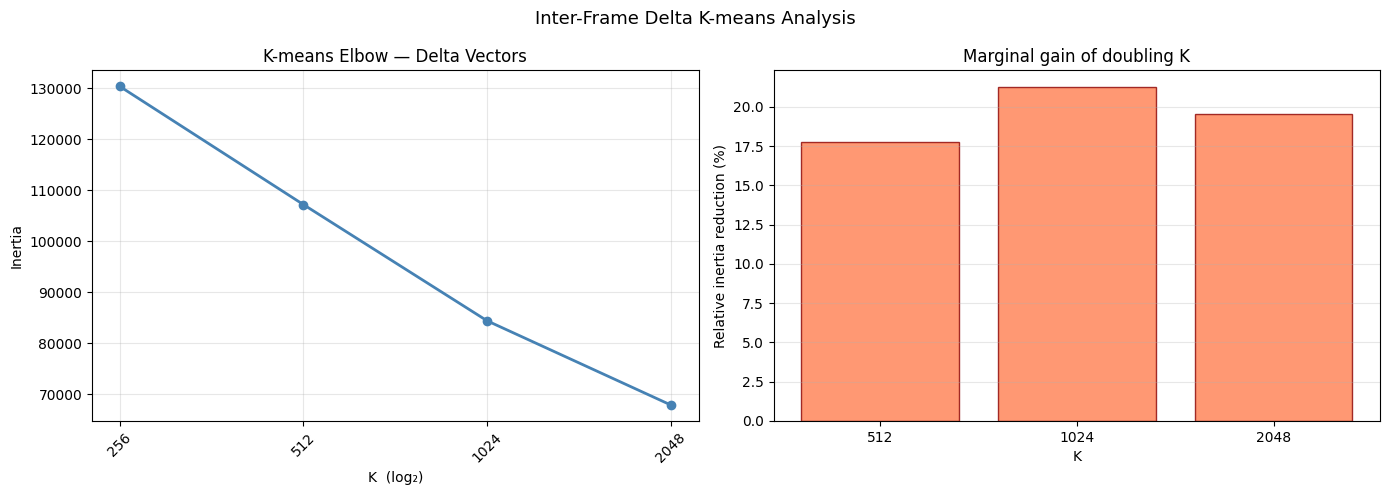

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans

# ── 11.5  K-means elbow analysis (library: build_codebook) ───────────────
K_VALUES = [256, 512, 1024, 2048]

# Standardize (reuse for elbow plot)
scaler = StandardScaler()
delta_scaled = scaler.fit_transform(delta_all)

inertias = []
print(f"K-means sweep ({N_G:,} Gaussians × {D} dims)")
for k in K_VALUES:
    km = MiniBatchKMeans(
        n_clusters=k, init='k-means++', n_init=3, max_iter=300,
        batch_size=min(10_000, N_G), random_state=42,
    )
    km.fit(delta_scaled)
    inertias.append(km.inertia_)
    print(f"  K={k:5d}  inertia={km.inertia_:,.1f}")
inertias = np.array(inertias)

# ── Elbow plot ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_VALUES, inertias, 'o-', color='steelblue', linewidth=2)
axes[0].set_xscale('log', base=2)
axes[0].set_xlabel('K  (log₂)'); axes[0].set_ylabel('Inertia')
axes[0].set_title('K-means Elbow — Delta Vectors'); axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(K_VALUES); axes[0].set_xticklabels([str(k) for k in K_VALUES], rotation=45)

rel_reductions = np.diff(inertias) / inertias[:-1]
axes[1].bar([str(k) for k in K_VALUES[1:]], -rel_reductions * 100,
            color='coral', alpha=0.8, edgecolor='darkred')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Relative inertia reduction (%)')
axes[1].set_title('Marginal gain of doubling K'); axes[1].grid(True, alpha=0.3, axis='y')
plt.suptitle('Inter-Frame Delta K-means Analysis', fontsize=13)
plt.tight_layout(); plt.show()

In [ ]:
# ── 11.6  Quantized delta reconstruction (library: build_codebook + split_delta) ─
from gsplat_compress.compression import split_delta, reconstruct_from_delta

K_EVAL = [256, 512, 1024]

# Reference: unquantised fine-tune render
with torch.no_grad():
    ref_render, _, _ = render(snap2.means, snap2.log_scales, snap2.quats,
                               snap2.rgbs, snap2.opacities, viewmat, K, W, H)
ref_np = np.clip(ref_render[:,:,0].cpu().numpy(), 0, 1)
target2_np = image_gray2.cpu().numpy()

ref_psnr = psnr(ref_np, target2_np)
ref_ssim = ssim(ref_np, target2_np)
print(f"Reference (unquantised fine-tune):  PSNR={ref_psnr:.2f} dB  SSIM={ref_ssim:.4f}\n")

results = []
for k in K_EVAL:
    # Build codebook via library
    labels_k, centroids_k, scaler_k = build_codebook(
        delta_all, CodebookConfig(n_clusters=k, kmeans_n_init=5, kmeans_max_iter=500),
    )
    # Apply quantised deltas
    quantised_delta = centroids_k[labels_k]   # [N, 14]
    d_m, d_s, d_q, d_r, d_o = split_delta(quantised_delta, device)
    rec = reconstruct_from_delta(snap1, d_m, d_s, d_q, d_r, d_o)

    with torch.no_grad():
        rec_render, _, _ = render(rec.means, rec.log_scales, rec.quats,
                                   rec.rgbs, rec.opacities, viewmat, K, W, H)
    rec_np = np.clip(rec_render[:,:,0].cpu().numpy(), 0, 1)
    p = psnr(rec_np, target2_np)
    s = ssim(rec_np, target2_np)
    results.append((k, p, s, rec_np))

    _bpp = 2 if USE_FP16 else 4
    codebook_bytes_k = k * D_FULL * _bpp
    index_bytes_k = math.ceil(N_G * math.ceil(math.log2(k)) / 8)
    print(f"  K={k:>4d}  PSNR={p:.2f} dB  SSIM={s:.4f}  "
          f"|codebook={codebook_bytes_k/1e3:.1f} kB  indices={index_bytes_k/1e3:.1f} kB|")

# ── Visualisation ─────────────────────────────────────────────────────────
n_cols = len(K_EVAL) + 2
fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 8))
def show(ax, img, title, cmap='gray', vmax=1):
    ax.imshow(img, cmap=cmap, vmin=0, vmax=vmax); ax.set_title(title, fontsize=8); ax.axis('off')

show(axes[0,0], target2_np, 'Image 2 target')
show(axes[1,0], np.abs(target2_np - target2_np), 'Error=0', cmap='hot', vmax=0.05)
show(axes[0,1], ref_np, f'Unquantised\n{ref_psnr:.1f} dB')
show(axes[1,1], np.abs(ref_np - target2_np), f'|err|', cmap='hot', vmax=0.05)
for j, (k, p, s, rec_np) in enumerate(results):
    show(axes[0, j+2], rec_np, f'K={k}\n{p:.1f} dB / SSIM={s:.3f}')
    show(axes[1, j+2], np.abs(rec_np - target2_np), f'|err|', cmap='hot', vmax=0.05)
plt.suptitle('Image 1 + Quantised Δ → Reconstructed Image 2', fontsize=12)
plt.tight_layout(); plt.show()

Reference (unquantised fine-tune):  PSNR=47.31 dB  SSIM=0.9831

  K= 256  PSNR=42.77 dB  SSIM=0.9702  |codebook=7.2 kB  indices=62.4 kB|
  K= 512  PSNR=43.03 dB  SSIM=0.9715  |codebook=14.3 kB  indices=70.2 kB|


## 12. Codebook Fine-tuning via Gradient Descent

Instead of keeping the 256 K-means centroids fixed, we fine-tune them directly against image 2.

**Setup:**
- Base Gaussians $X$ (`snap1_*`) are **frozen** — no gradients, no updates
- Learnable: codebook $C \in \mathbb{R}^{256 \times 14}$, initialised from K-means centroids
- Each Gaussian $i$ is assigned label $\ell_i \in \{0, \ldots, 255\}$ (fixed integer lookup from K-means)
- Reconstructed parameters: $\theta_i = X_i + C[\ell_i]$
- Loss: MSE between $\hat{Y} = \text{render}(\theta)$ and target $Y$ (image 2)
- Gradient flows only into the 256 rows of $C$ that were used; the indexing `C[labels]` accumulates gradients from all $N/256 \approx 393$ Gaussians per centroid on average

This is a **structured bottleneck fine-tune**: the full $N \times 14$ degree of freedom is compressed to $256 \times 14 = 3584$ free scalars.

In [ ]:
# ── 12.  Codebook fine-tuning via the library (encode_delta_frame) ────────
K_CB = 4096

cb_cfg = CodebookConfig(
    n_clusters=K_CB,
    kmeans_n_init=10,
    kmeans_max_iter=500,
    finetune_iter=2000,
    finetune_lr=5e-3,
    use_fp16=USE_FP16,
)

# Full delta encoding pipeline: deltas → K-means → codebook fine-tune
compressed_f2, reconstructed_f2 = encode_delta_frame(
    snap1, snap2, gt_image2, viewmat, K, W, H, cb_cfg, verbose=True,
)

# ── Evaluate quality ──────────────────────────────────────────────────────
with torch.no_grad():
    ft_cb_render, _, _ = render(
        reconstructed_f2.means, reconstructed_f2.log_scales,
        reconstructed_f2.quats, reconstructed_f2.rgbs, reconstructed_f2.opacities,
        viewmat, K, W, H,
    )
ft_cb_np = np.clip(ft_cb_render[:,:,0].cpu().numpy(), 0, 1)
psnr_after = psnr(ft_cb_np, target2_np)
ssim_after = ssim(ft_cb_np, target2_np)

print(f"\n{'='*55}")
print(f"  Codebook fine-tune result (K={K_CB})")
print(f"{'='*55}")
print(f"  After  codebook fine-tune : PSNR={psnr_after:.2f} dB  SSIM={ssim_after:.4f}")
print(f"  Unquantised upper bound   : PSNR={ref_psnr:.2f} dB  SSIM={ref_ssim:.4f}")
print(f"{'='*55}")

# Storage
d_bytes = compressed_f2.storage_bytes(USE_FP16)
print(f"\n  Delta storage (K={K_CB}): {d_bytes['total_bytes']/1e3:.1f} kB  "
      f"(codebook={d_bytes['codebook_bytes']/1e3:.1f} kB + "
      f"labels={d_bytes['label_bytes']/1e3:.1f} kB)")

# ── Visualisation ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(target2_np, cmap='gray', vmin=0, vmax=1)
axes[0].set_title('Target (image 2)'); axes[0].axis('off')
axes[1].imshow(ref_np, cmap='gray', vmin=0, vmax=1)
axes[1].set_title(f'Unquantised FT\n{ref_psnr:.2f} dB'); axes[1].axis('off')
axes[2].imshow(ft_cb_np, cmap='gray', vmin=0, vmax=1)
axes[2].set_title(f'Codebook FT K={K_CB}\n{psnr_after:.2f} dB'); axes[2].axis('off')
axes[3].imshow(np.abs(ft_cb_np - target2_np), cmap='hot', vmin=0, vmax=0.06)
axes[3].set_title(f'|Error|'); axes[3].axis('off')
plt.tight_layout(); plt.show()

## 13. Codebook Fine-tune Sweep — All K + Compression Analysis

For each codebook size K we:
1. Fit K-means on the standardised delta vectors
2. Fine-tune the K centroids via gradient descent (base Gaussians frozen)
3. Render and measure PSNR / SSIM
4. Compute storage sizes and compression ratio vs. the raw second frame

**Storage accounting (frame-2 incremental cost):**
- *Codebook*: $K \times D_{\text{eff}} \times 4$ bytes, where $D_{\text{eff}}=8$ after dropping the 6
  parameters confirmed to be exactly zero / redundant in the delta
  (Δmean_z, Δscale_z, Δquat_x, Δquat_y are always 0; Δrgb_g = Δrgb_b = Δrgb_r)
- *Labels*: $N \times \lceil\log_2 K\rceil$ bits → bytes
- *Reference*: raw frame 2 = $H \times W \times 2$ bytes (int16)

In [ ]:
K_SWEEP = [512, 1024, 2048, 4096]
NUM_ITER_SW = 2000
LR_SW = 5e-4

raw_frame2_bytes = raw_frame_bytes(H, W)
base_eff_bytes = keyframe_bytes(N_G, USE_FP16)

print(f"Sweep K = {K_SWEEP}")
print(f"D_eff = {D_EFF},  Raw frame-2: {raw_frame2_bytes/1e3:.1f} kB")
print(f"Base frame-1: {base_eff_bytes/1e6:.2f} MB")
print(f"Unquantised ref: PSNR={ref_psnr:.2f} dB  SSIM={ref_ssim:.4f}")
print("=" * 72)

sweep_results = []
for k_sw in K_SWEEP:
    sw_cfg = CodebookConfig(
        n_clusters=k_sw,
        kmeans_n_init=10,
        kmeans_max_iter=500,
        finetune_iter=NUM_ITER_SW,
        finetune_lr=LR_SW,
        use_fp16=USE_FP16,
    )
    compressed_sw, rec_sw = encode_delta_frame(
        snap1, snap2, gt_image2, viewmat, K, W, H, sw_cfg, verbose=False,
    )

    # Render and measure quality
    with torch.no_grad():
        rend_sw, _, _ = render(rec_sw.means, rec_sw.log_scales, rec_sw.quats,
                                rec_sw.rgbs, rec_sw.opacities, viewmat, K, W, H)
    rec_np_sw = np.clip(rend_sw[:,:,0].cpu().numpy(), 0, 1)
    psnr_ft = psnr(rec_np_sw, target2_np)
    ssim_ft = ssim(rec_np_sw, target2_np)

    d_info = compressed_sw.storage_bytes(USE_FP16)
    delta_bytes_sw = d_info['total_bytes']
    total_bytes_sw = base_eff_bytes + delta_bytes_sw
    cr_incr = raw_frame2_bytes / delta_bytes_sw
    cr_total = raw_frame2_bytes / total_bytes_sw

    sweep_results.append(dict(
        K=k_sw, psnr_ft=psnr_ft, ssim_ft=ssim_ft,
        delta_bytes=delta_bytes_sw, total_bytes=total_bytes_sw,
        cr_incr=cr_incr, cr_total=cr_total,
    ))
    print(f"  K={k_sw:>5d}  PSNR={psnr_ft:.2f} dB  SSIM={ssim_ft:.4f}  "
          f"|Δ|={delta_bytes_sw/1e3:.1f} kB  cr_incr={cr_incr:.2f}×")

print("\n✅ Sweep complete")

# ── Summary table ─────────────────────────────────────────────────────────
print(f"\n{'K':>6} {'PSNR_FT':>9} {'SSIM_FT':>8} {'Δ_kB':>8} {'cr_incr':>9} {'cr_total':>10}")
print("-" * 60)
for r in sweep_results:
    print(f"{r['K']:>6d} {r['psnr_ft']:>9.2f} {r['ssim_ft']:>8.4f} "
          f"{r['delta_bytes']/1e3:>8.1f} {r['cr_incr']:>9.2f}× {r['cr_total']:>9.5f}×")

# ── Plots ─────────────────────────────────────────────────────────────────
Ks       = [r['K']          for r in sweep_results]
psnr_fts = [r['psnr_ft']    for r in sweep_results]
ssim_fts = [r['ssim_ft']    for r in sweep_results]
delta_kb = [r['delta_bytes']/1e3  for r in sweep_results]
cr_incrs = [r['cr_incr']    for r in sweep_results]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes[0,0].semilogx(Ks, psnr_fts, 'o-', color='steelblue', linewidth=2, base=2)
axes[0,0].axhline(ref_psnr, color='red', linestyle=':', linewidth=1.5,
                   label=f'Unquantised ({ref_psnr:.1f} dB)')
axes[0,0].set_xlabel('K'); axes[0,0].set_ylabel('PSNR (dB)')
axes[0,0].set_title('Quality vs codebook size'); axes[0,0].legend(fontsize=8)
axes[0,0].set_xticks(Ks); axes[0,0].set_xticklabels([str(k) for k in Ks], rotation=45)
axes[0,0].grid(True, alpha=0.3)

axes[0,1].semilogx(Ks, ssim_fts, 'o-', color='darkgreen', linewidth=2, base=2)
axes[0,1].axhline(ref_ssim, color='red', linestyle=':', linewidth=1.5)
axes[0,1].set_xlabel('K'); axes[0,1].set_ylabel('SSIM')
axes[0,1].set_title('SSIM vs codebook size'); axes[0,1].grid(True, alpha=0.3)
axes[0,1].set_xticks(Ks); axes[0,1].set_xticklabels([str(k) for k in Ks], rotation=45)

axes[0,2].axis('off')  # empty

axes[1,0].semilogx(Ks, delta_kb, 'o-', color='darkorange', linewidth=2, base=2)
axes[1,0].axhline(raw_frame2_bytes/1e3, color='black', linestyle='--', linewidth=1.2,
                   label=f'Raw frame ({raw_frame2_bytes/1e3:.0f} kB)')
axes[1,0].set_xlabel('K'); axes[1,0].set_ylabel('Delta storage (kB)')
axes[1,0].set_title('Delta size vs K'); axes[1,0].legend(fontsize=8); axes[1,0].grid(True, alpha=0.3)
axes[1,0].set_xticks(Ks); axes[1,0].set_xticklabels([str(k) for k in Ks], rotation=45)

axes[1,1].plot(delta_kb, psnr_fts, 'o-', color='steelblue', linewidth=2)
for r in sweep_results:
    axes[1,1].annotate(f'K={r["K"]}', (r['delta_bytes']/1e3, r['psnr_ft']),
                        textcoords='offset points', xytext=(4, 3), fontsize=7)
axes[1,1].set_xlabel('Delta storage (kB)'); axes[1,1].set_ylabel('PSNR (dB)')
axes[1,1].set_title('Rate–Distortion'); axes[1,1].grid(True, alpha=0.3)

axes[1,2].semilogx(Ks, cr_incrs, 'o-', color='teal', linewidth=2, base=2)
axes[1,2].axhline(1.0, color='black', linestyle='--', linewidth=1)
axes[1,2].set_xlabel('K'); axes[1,2].set_ylabel('Compression ratio')
axes[1,2].set_title('Incremental CR vs K'); axes[1,2].grid(True, alpha=0.3)
axes[1,2].set_xticks(Ks); axes[1,2].set_xticklabels([str(k) for k in Ks], rotation=45)

plt.suptitle(f'Codebook Fine-tune Sweep (D_eff={D_EFF}, {N_G:,} Gaussians)', fontsize=13)
plt.tight_layout(); plt.show()